In [66]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformer import Transformer
import math
import torch.nn.functional as F

We'll load the data from running the model.

In [74]:
data = np.load('logs.npz')
train_loss = data['train_loss']
test_loss = data['test_loss']
train_acc = data['train_acc']
test_acc = data['test_acc']

epochs = 40000
x_val = range(0, epochs, 100)

We'll show the plots for the first 20000 epochs; the last 20000 are not so interesting (they're relatively consistent with the preceding ~15000 epochs.)

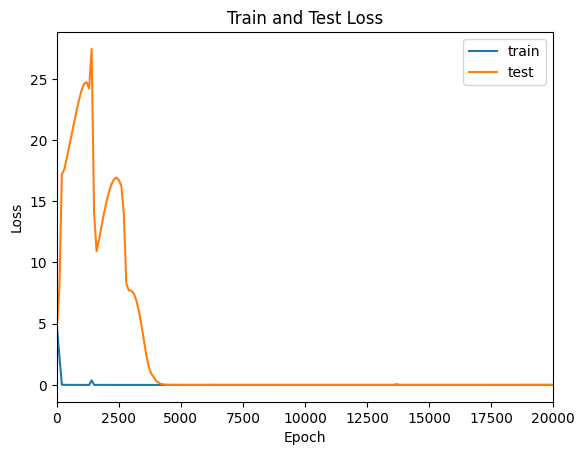

In [75]:
plt.plot(x_val, train_loss, label = 'train')
plt.plot(x_val, test_loss, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Test Loss')
plt.xlim(0,20000)
plt.legend()
plt.savefig('figures/loss.png')
plt.show()

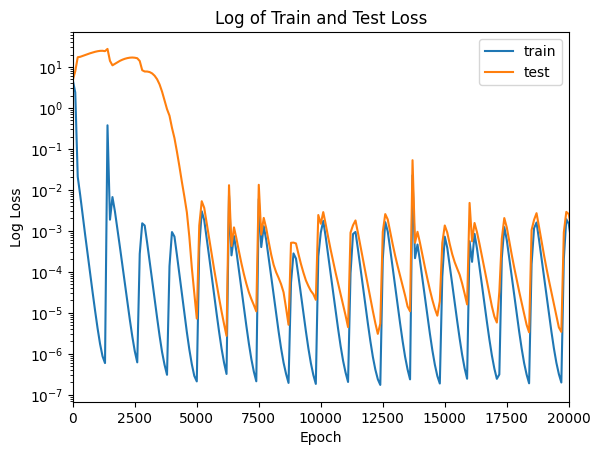

In [76]:
plt.plot(x_val, train_loss, label = 'train')
plt.plot(x_val, test_loss, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Log of Train and Test Loss')
plt.yscale('log')
plt.xlim(0,20000)
plt.legend()
plt.savefig("figures/log_loss.png")
plt.show()

The train loss descends to ~0 very quickly, whereas the test loss remains high for a few thousand epochs, then also descends to ~0. The log-scale plot shows oscillations between lower and higher losses, but all still, on the absolute scale, quite low.

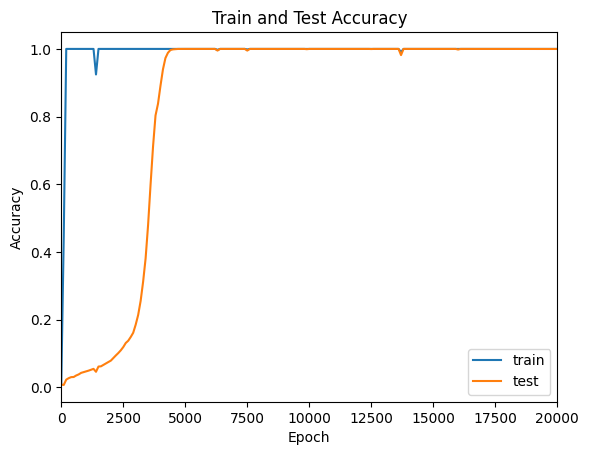

In [77]:
plt.plot(x_val, train_acc, label = 'train')
plt.plot(x_val, test_acc, label = 'test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy')
plt.xlim(0,20000)
plt.legend()
plt.savefig("figures/acc.png")
plt.show()

Training accuracy ascends to ~1 almost immediately, and test accuracy remains relatively low for a few thousand epochs before rapidly ascending to ~1. Now we'll proceed to Fourier analysis of the weights.

In [31]:
# load model
model = Transformer()
model.load_state_dict(torch.load('model.pth'))

# load embedding and unembedding matrices
We = model.We.detach() # 114 diff chars; each row corresponds to an embedding in 128-dimensional space; 114 x 128
Wu = model.Wu.detach() # after processing the input, we get 128-dimensional vectors at position 2 ('='). need to project them into 114-dimensional space to predict. 128 x 114

We'll build the Fourier basis vectors.

In [ ]:
N = 113
M = int((N+1)/2)

fourier_basis = []
for k in range(1,M):
    # each sin basis vector looks as follows: [sin((2kpi*0)/113), sin((2kpi*1)/113), ..., sin((2kpi*112)/113)]
    fourier_basis.append([math.sin(2 * k * math.pi * x / N) for x in range(N)])

for k in range(1,M):
    # each cos basis vector looks as follows: [cos((2kpi*0)/113), cos((2kpi*1)/113), ..., cos((2kpi*112)/113)]
    fourier_basis.append([math.cos(2 * k * math.pi * x / N) for x in range(N)])

# add the all-ones vector
fourier_basis.append([1] * N)
fourier_basis = torch.tensor(fourier_basis)

# normalize
fourier_basis = F.normalize(fourier_basis, dim = 1)


Next, we'll project the embedding matrix onto the Fourier basis. 

A bit of math first. Call our weight embedding matrix $W_e$; we'll use the first 113 rows (every row except the row corresponding to the '='.) Represent it as $[w_1, w_2, \ldots , w_{128}]$, where the $w_i$'s are $113$-dimensional column vectors. They can be thought of as containing the $i$-th dimension coordinate for each embedding of each character.

Call our Fourier basis matrix $F$; represent it as $\begin{bmatrix}  b_1 \\ b_2 \\ \vdots \\ b_{113} \end{bmatrix}$. Here the basis vectors are $113$-dimensional and orthonormal (that is, they have norm $1$ and are all orthogonal to each other.)

The projection matrix is 
$$P = FW_e = \begin{bmatrix}
b_1 \cdot w_1 & b_1 \cdot w_2 & \cdots & b_1 \cdot w_{128} \\
b_2 \cdot w_1 & b_2 \cdot w_2 & \cdots & b_2 \cdot w_{128} \\
\vdots & \vdots & \ddots & \vdots \\
b_{113} \cdot w_1 & b_{113} \cdot w_2 & \cdots & b_{113} \cdot w_{128}
\end{bmatrix}.$$

We will note that this matrix $P$ has the property that $P^T F = W_e^T$. That is, we'll claim that
\begin{align*}
\begin{bmatrix}
b_1 \cdot w_1 & b_2 \cdot w_1 & \cdots & b_{113} \cdot w_1 \\
b_1 \cdot w_2 & b_2 \cdot w_2 & \cdots & b_{113} \cdot w_2 \\
\vdots & \vdots & \ddots & \vdots \\
b_1 \cdot w_{128} & b_2 \cdot w_{128} & \cdots & b_{113} \cdot w_{128}
\end{bmatrix} \begin{bmatrix}  b_1 \\ b_2 \\ \vdots \\ b_{113} \end{bmatrix} = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_{128} \end{bmatrix}.
\end{align*}
Consider the $j$-th row of this multiplication. We'd like 
$$(b_1 \cdot w_j) b_1 + \ldots + (b_{113} \cdot w_j) b_{113} = w_j.$$

As $\{b_1, \ldots , b_{113}\}$ comprises a basis for $\mathbb{R}^{113}$, we know that
$$w_j = c_1 b_1 + \ldots + c_{113} b_{113}$$
for some constants $c_1, \ldots , c_{113}$. Dot both sides by $b_k$. We obtain
\begin{align*}w_j \cdot b_k & = c_1 (b_1 \cdot b_k) + \ldots + c_{113} (b_{113} \cdot b_k) \\
& = c_k (b_k \cdot b_k) \\ &= c_k
\end{align*}
where we've used that the basis is orthonormal to conclude $b_i \cdot b_k = 0$ when $i \neq k$ and $b_k \cdot b_k = 1$. Then we substitute this back in to get
\begin{align*}
w_j &= c_1 b_1 + \ldots + c_{113} b_{113} \\
&= (w_j \cdot b_1) b_1 + \ldots + (w_j \cdot b_{113}) b_{113}\end{align*}
as desired.

In [113]:
# get the first 113 rows; the 114th corresponds to the equals sign
We_num = We[:113,:]
projections_e = fourier_basis @ We_num # 113 x 128

Next we want the norms for each row of the projection matrix.

The first row of the projection matrix is $[b_1\cdot w_1, b_1 \cdot w_2, \ldots , b_1 \cdot w_{128}]$. Note that the entry $b_1 \cdot w_j$ can be thought of as the contribution from $b_1$ to $w_j$ in the decomposition of $w_j$ into a linear combination of basis vectors $b_1, \ldots , b_{113}$. Thus the norm $\sqrt{(b_1 \cdot w_1)^2 + \ldots + (b_1 \cdot w_{128})^2}$ can be thought of as the total contribution from $b_1$ toward the weight matrix. 

More generally speaking then, the $i$-th row of the norms matrix will represent the total contribution from $b_i$ toward the embedding matrix. We will identify the basis vectors that have the largest contributions toward the embedding matrix.

In [116]:
norms_e = torch.linalg.vector_norm(projections_e, dim = 1)
torch.topk(norms_e, k = 10)

torch.return_types.topk(
values=tensor([5.9188, 5.5826, 5.5478, 5.2969, 5.1249, 5.0590, 4.6011, 4.5009, 2.0585,
        1.8899]),
indices=tensor([ 48,  68, 104,  38,  94,  12,  74,  18,  34,  90]))

Basis vectors $b_i$ with $i = 48, 68, 104, 38, 94, 12, 74, 18, 34, 90$ (for the basis matrix in the code) contribute much more toward the embedding matrix than the rest of the basis vectors.

Note that these correspond to normalized versions of the following basis vectors, mathematically speaking: $\left[\sin( \frac{2k \pi \cdot 0}{113}), \sin( \frac{2k \pi \cdot 1}{113}), ..., \sin( \frac{2k \pi \cdot 112}{113})\right]$ for $k = 13, 19, 35, 39, 49$, and $\left[\cos( \frac{2k \pi \cdot 0}{113}), \cos( \frac{2k \pi \cdot 1}{113}), ..., \cos( \frac{2k \pi \cdot 112}{113})\right]$ for $k = 13, 19, 35, 39, 49$ too; recall that the $\sin$ vectors correspond to rows $1-56$, the $\cos$ vectors correspond to rows $57-112$, and the all-ones vector is row $113$.

Next, we'll analyze $W_L$, which in the paper is the matrix that is one component of the mapping of MLP activations to logits, $W_2 W_U$.

In [131]:
W2 = model.mlp.W2.detach()
Wu = model.Wu.detach()
WL = W2 @ Wu 
WL_num = WL[:,:113].T
WL_num.shape

torch.Size([113, 512])

In [132]:
projections_L = fourier_basis @ WL_num # 113 x 512
norms_L = torch.linalg.vector_norm(projections_L, dim = 1)
torch.topk(norms_L, k = 10)

torch.return_types.topk(
values=tensor([12.9304,  8.9835,  8.6406,  8.2650,  8.0828,  7.8944,  6.9489,  6.7799,
         5.5313,  1.7409]),
indices=tensor([112,  94, 104,  38,  12,  68,  48,  74,  18,  14]))

Note that these correspond to $k = 13, 15, 19, 39, 49$ for the $\sin$ vectors, $k = 13, 19, 39, 49$ for the $\cos$ vectors, and the all-ones vector.